# Global Sales Portfolio Analysis: Identifying High-Performing Markets and Product Segments

This project analyzes a [global sales dataset sourced from GitHub Gist](https://gist.github.com/denandreychuk/b9aa812f10e4b60368cff69c6384a210) containing country-level performance records across multiple regions, product categories, and sales channels. The dataset includes key commercial metrics such as units sold, pricing, revenue, cost, and profit.

The objective of this analysis is to understand how revenue and profitability vary across markets and product segments. By examining patterns in sales performance, we can identify which regions, product categories, and distribution channels contribute the most value to the business.

The findings aim to support strategic decision-making by highlighting opportunities for revenue growth while maintaining strong profit margins.

## Problem Statement
How can the company increase total revenue and profitability by identifying the highest-performing regional and product segments, while managing geographic and channel concentration risk?

## Data Overview

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load dataset
df=pd.read_csv("100_sales_records.csv")
#preview first few rows
df.head(5)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [3]:
#dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    str    
 1   Country         100 non-null    str    
 2   Item Type       100 non-null    str    
 3   Sales Channel   100 non-null    str    
 4   Order Priority  100 non-null    str    
 5   Order Date      100 non-null    str    
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    str    
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), str(7)
memory usage: 16.9 KB


In [4]:
#summary statistics
df.describe()

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+02,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02
mean,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
std,2.606153e+08,2794.484562,235.592241,188.208181,1.460029e+06,1.083938e+06,4.385379e+05
min,1.146066e+08,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03
25%,3.389225e+08,2836.250000,81.730000,35.840000,2.687212e+05,1.688680e+05,1.214436e+05
50%,5.577086e+08,5382.500000,179.880000,107.275000,7.523144e+05,3.635664e+05,2.907680e+05
75%,7.907551e+08,7369.000000,437.200000,263.330000,2.212045e+06,1.613870e+06,6.358288e+05
max,9.940222e+08,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06


### Findings from Summary Statistics
- **Units Sold:** Countries sell an average of ~5,129 units, with volumes ranging from 124 to 9,925 units, indicating significant variation in demand across markets.
- **Unit Price:** Prices vary widely, ranging from USD 9.33 to USD 668.27, suggesting a mix of low-cost and premium product segments.
- **Total Revenue:** The average revenue generated per country record is approximately USD 1.37M, with the highest-performing markets reaching nearly USD 6M in revenue.
- **Total Profit:** Profit averages around USD 442K, with top-performing records generating up to USD 1.72M.

Overall, this indicates substantial variation in sales volume, pricing, and profitability across markets and product segments. 

## Diagnostic Analysis
### 1. What’s the Total Revenue by Region, Item Type, and Sales Channel?
#### 1.1. Revenue by Region

In [5]:
#Calculate revenue by region (in millions)
region_revenue_millions = df.groupby("Region")["Total Revenue"].sum().sort_values(ascending=False) / 1000000
region_revenue_millions

Region
Sub-Saharan Africa                   39.672031
Europe                               33.368932
Asia                                 21.347091
Australia and Oceania                14.094265
Middle East and North Africa         14.052707
Central America and the Caribbean     9.170385
North America                         5.643357
Name: Total Revenue, dtype: float64

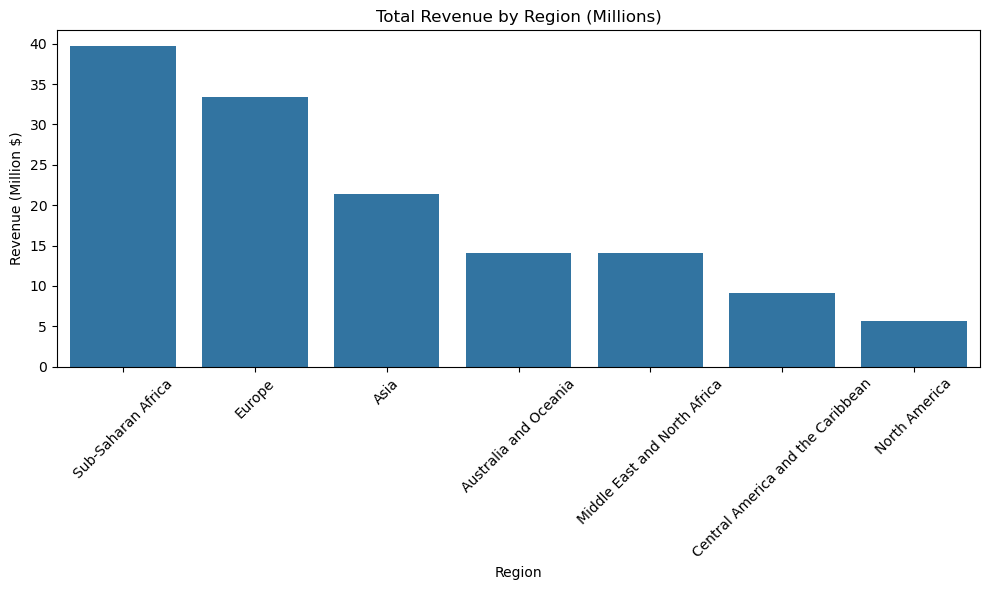

In [6]:
#plotting above in bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=region_revenue_millions.index, y=region_revenue_millions.values)
plt.title("Total Revenue by Region (Millions)")
plt.ylabel("Revenue (Million $)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Key Insight:
Revenue is concentrated in **Sub-Saharan Africa** and **Europe**, which together account for over 50% of the total revenue. 

#### 1.2. Revenue by Item Type

In [7]:
#calculate revenue by item type in millions
item_revenue_millions = df.groupby("Item Type")["Total Revenue"].sum().sort_values(ascending=False) / 1000000
item_revenue_millions

Item Type
Cosmetics          36.601510
Office Supplies    30.585380
Household          29.889712
Baby Food          10.350328
Clothes             7.787293
Cereal              5.322899
Meat                4.503676
Personal Care       3.980905
Vegetables          3.089057
Beverages           2.690795
Snacks              2.080733
Fruits              0.466481
Name: Total Revenue, dtype: float64

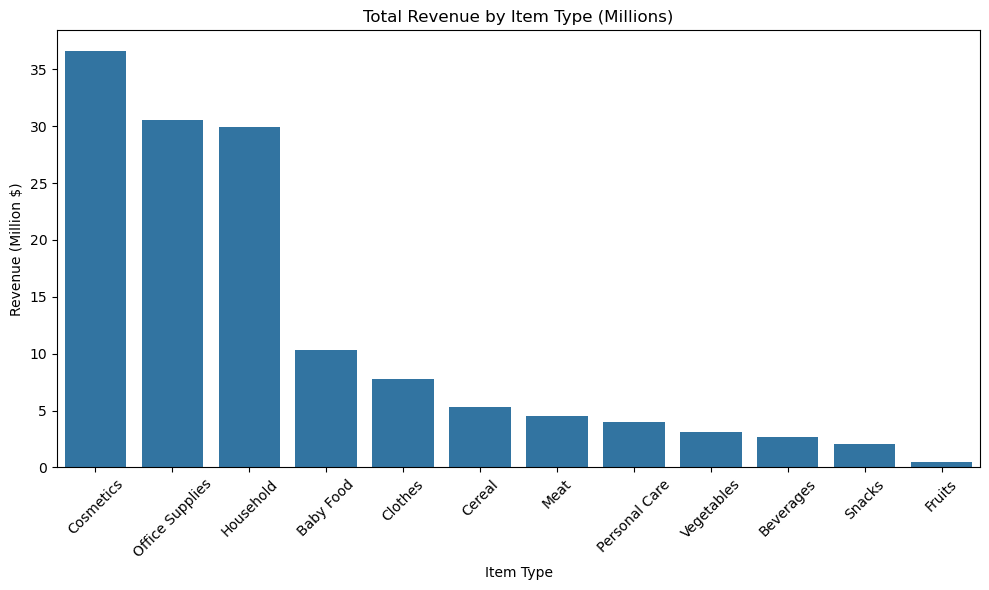

In [8]:
#plot revenue by item type in 
plt.figure(figsize=(10,6))
sns.barplot(x=item_revenue_millions.index, y=item_revenue_millions.values)
plt.title("Total Revenue by Item Type (Millions)")
plt.ylabel("Revenue (Million $)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Key Insight: 
**Cosmetics**, **Office Supplies**, and **Household** goods dominate revenue, while **Fruits** contribute almost nothing.

#### 1.3. Revenue by Sales Channel

In [9]:
#calculate revenue by sales channel in millions
channel_revenue_millions = df.groupby("Sales Channel")["Total Revenue"].sum().sort_values(ascending=False) / 1000000
channel_revenue_millions

Sales Channel
Offline    79.094809
Online     58.253959
Name: Total Revenue, dtype: float64

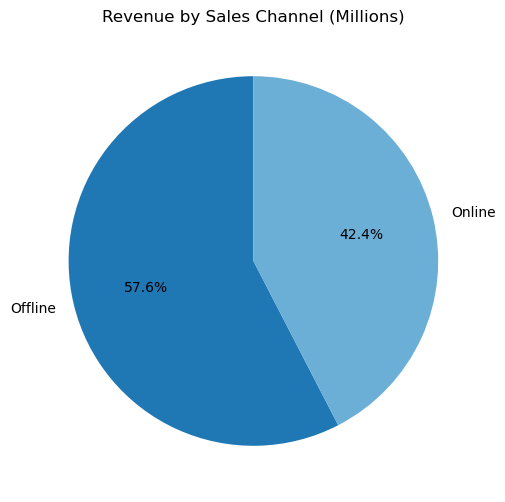

In [10]:
#plot revenue by sales channel
plt.figure(figsize=(6,6))
plt.pie(
    channel_revenue_millions.values,
    labels=channel_revenue_millions.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#1f77b4", "#6baed6"]  # optional: two greens for consistency
)
plt.title("Revenue by Sales Channel (Millions)")
plt.show()

##### Key Insight: 
**Offline sales** generate the majority of revenue, suggesting stronger performance in traditional channels.

### 2. Which Regions and Product Categories Contribute to the Largest Share of Total Revenue, and How Concentrated is Revenue Among the Top Performers? 

In [11]:
#calculate revenue share by region (%)
region_share = (region_revenue_millions / region_revenue_millions.sum()) * 100
#calculate cumulate % revenue share by region
cumulative_share = np.cumsum(region_share.values)

#top 3 regions
top_regions = region_revenue_millions.head(3)
top_regions_share = region_share.head(3)

print("Top 3 Regions by Revenue (Millions):")
print(top_regions)
print("\n% Revenue Contribution of Top 3 Regions:")
print(top_regions_share)

Top 3 Regions by Revenue (Millions):
Region
Sub-Saharan Africa    39.672031
Europe                33.368932
Asia                  21.347091
Name: Total Revenue, dtype: float64

% Revenue Contribution of Top 3 Regions:
Region
Sub-Saharan Africa    28.884155
Europe                24.295036
Asia                  15.542252
Name: Total Revenue, dtype: float64


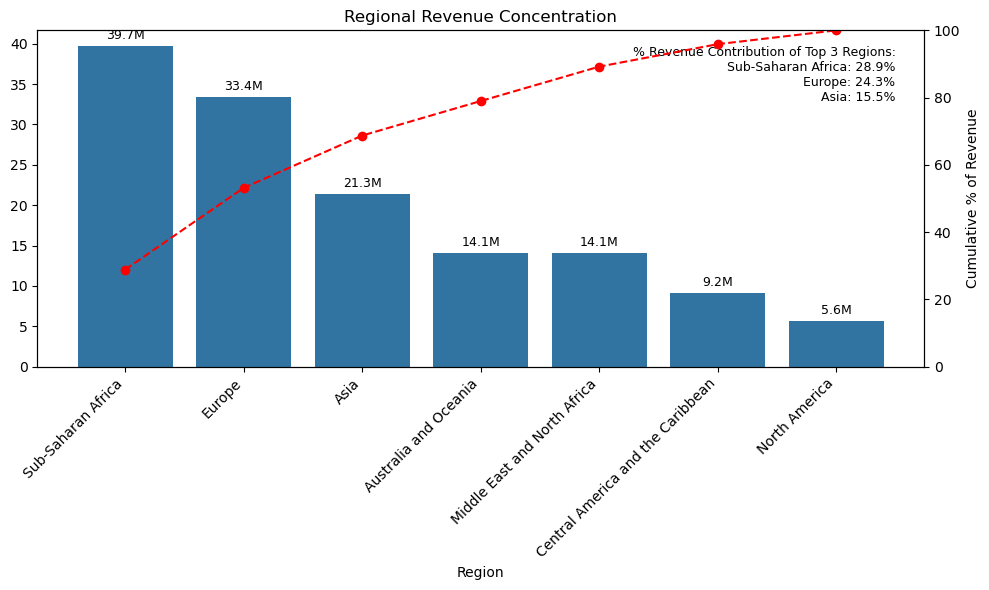

In [12]:
#plot top 3 regions in pareto-style chart
#but first define the caption 
caption = (
    "% Revenue Contribution of Top 3 Regions:\n"
    "Sub-Saharan Africa: 28.9%\n"
    "Europe: 24.3%\n"
    "Asia: 15.5%")

#now the chart
plt.figure(figsize=(10,6))
ax = sns.barplot(x=region_revenue_millions.index, y=region_revenue_millions.values, color="#1f77b4")

#ddd data labels
for i, v in enumerate(region_revenue_millions.values):
    ax.text(i, v + 0.5, f"{v:.1f}M", ha="center", va="bottom", fontsize=9)

#rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

#add cumulative % revenue share line
cumulative_share = np.cumsum(region_share.values)
ax2 = ax.twinx()
ax2.plot(region_revenue_millions.index, cumulative_share, color="red", marker="o", linestyle="--")
ax2.set_ylabel("Revenue (Million $)")
ax2.set_ylim(0, 100)

#add caption inside chart (bottom left corner)
ax.text(
    len(region_revenue_millions)-0.5,   #place the caption near last bar
    max(region_revenue_millions.values), #and at the top of the chart
    caption,
    ha="right", va="top", fontsize=9, color="black",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

plt.ylabel("Cumulative % of Revenue")
plt.title("Regional Revenue Concentration")
plt.tight_layout()
plt.show()

In [13]:
#calculate revenue share by item type (%)
item_share = (item_revenue_millions / item_revenue_millions.sum()) * 100

#top 5 item types
top_items = item_revenue_millions.head(5)
top_items_share = item_share.head(5)

print("\nTop 5 Item Types by Revenue (Millions):")
print(top_items)
print("\n% Revenue Contribution of Top 5 Item Types:")
print(top_items_share)



Top 5 Item Types by Revenue (Millions):
Item Type
Cosmetics          36.601510
Office Supplies    30.585380
Household          29.889712
Baby Food          10.350328
Clothes             7.787293
Name: Total Revenue, dtype: float64

% Revenue Contribution of Top 5 Item Types:
Item Type
Cosmetics          26.648590
Office Supplies    22.268405
Household          21.761908
Baby Food           7.535799
Clothes             5.669722
Name: Total Revenue, dtype: float64


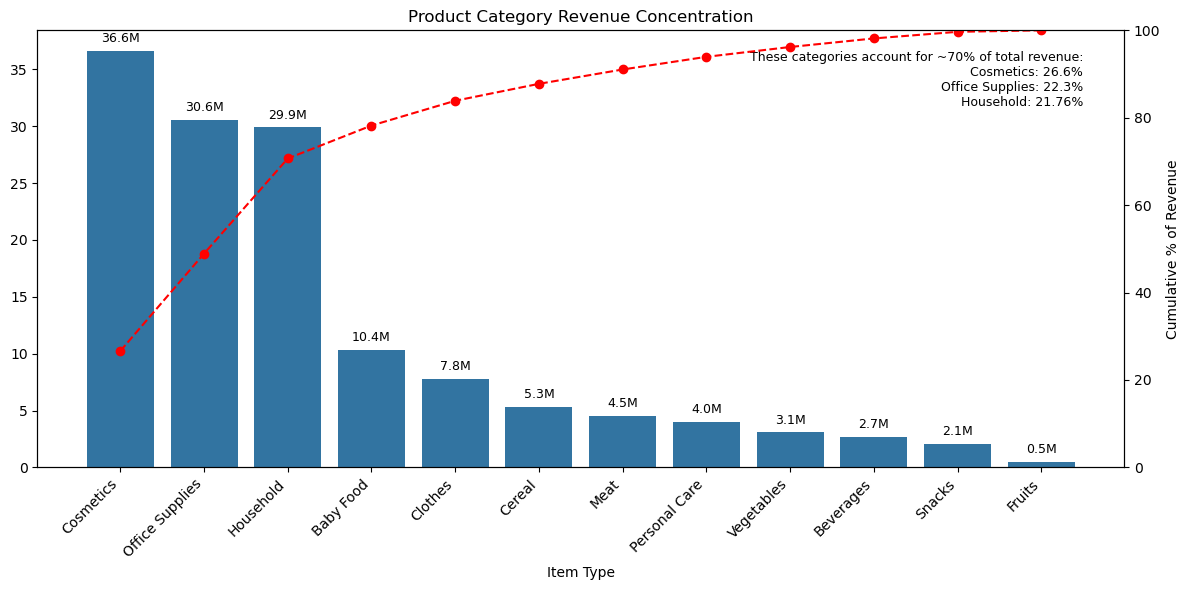

In [14]:
#define caption for top 5 item types
caption_items = (
    "These categories account for ~70% of total revenue:\n"
    "Cosmetics: 26.6%\n"
    "Office Supplies: 22.3%\n"
    "Household: 21.76%\n")

#plot pareto-style chart for top 5 item types
plt.figure(figsize=(12,6))
ax = sns.barplot(x=item_revenue_millions.index, y=item_revenue_millions.values, color="#1f77b4")

#add data labels
for i, v in enumerate(item_revenue_millions.values):
    ax.text(i, v + 0.5, f"{v:.1f}M", ha="center", va="bottom", fontsize=9)

#rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

#add cumulative % revenue share line
cumulative_item_share = np.cumsum(item_share.values)
ax2 = ax.twinx()
ax2.plot(item_revenue_millions.index, cumulative_item_share, color="red", marker="o", linestyle="--")
ax2.set_ylabel("Revenue (Million $)")
ax2.set_ylim(0, 100)

#sdd caption inside chart (top-right corner)
ax.text(
    len(item_revenue_millions)-0.5,   # near last bar
    max(item_revenue_millions.values), # top of chart
    caption_items,
    ha="right", va="top", fontsize=9, color="black",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

plt.ylabel("Cumulative % of Revenue")
plt.title("Product Category Revenue Concentration")
plt.tight_layout()
plt.show()

##### Key Insights:
- **Regions:** The top 3 regions contribute ~69% of total revenue. Sub-Saharan Africa and Europe alone account for over half, underscoring geographic concentration.
- **Item Types:** The top 5 categories contribute ~84% of total revenue. Cosmetics, Office Supplies, and Household alone drive ~70%, while Baby Food and Clothes add modest shares. The steep drop after the top 3 highlights concentration risk.

### 3.Is High Revenue Driven by Volume (Units Sold), Pricing, or Margin Differences Across Segments?

In [15]:
#create profit margin column
df["Profit Margin"] = df["Total Profit"] / df["Total Revenue"]

#aggregate metrics by Item Type
metrics = df.groupby("Item Type")[["Units Sold","Unit Price","Profit Margin"]].mean()
metrics

,Units Sold,Unit Price,Profit Margin
Item Type,,,
Baby Food,5792.142857,255.28,0.375509
Beverages,7088.500000,47.45,0.330032
Cereal,3696.714286,205.70,0.430676
Clothes,5481.538462,109.28,0.672035
Cosmetics,6439.846154,437.20,0.397690
Fruits,4999.800000,9.33,0.258307
Household,4969.666667,668.27,0.247999
Meat,5337.500000,421.89,0.135580
Office Supplies,3913.916667,651.21,0.193870


In [16]:
#normalize metrics to allow for more accurate comparison
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
metrics_scaled = pd.DataFrame(
    scaler.fit_transform(metrics),
    columns=metrics.columns,
    index=metrics.index)

metrics_scaled

,Units Sold,Unit Price,Profit Margin
Item Type,,,
Baby Food,0.653997,0.373251,0.447249
Beverages,1.000000,0.057850,0.362475
Cereal,0.094719,0.298009,0.550084
Clothes,0.571096,0.151683,1.000000
Cosmetics,0.826872,0.649331,0.488596
Fruits,0.442518,0.000000,0.228773
Household,0.434475,1.000000,0.209558
Meat,0.532651,0.626096,0.000000
Office Supplies,0.152691,0.974110,0.108657


<Figure size 1200x600 with 0 Axes>

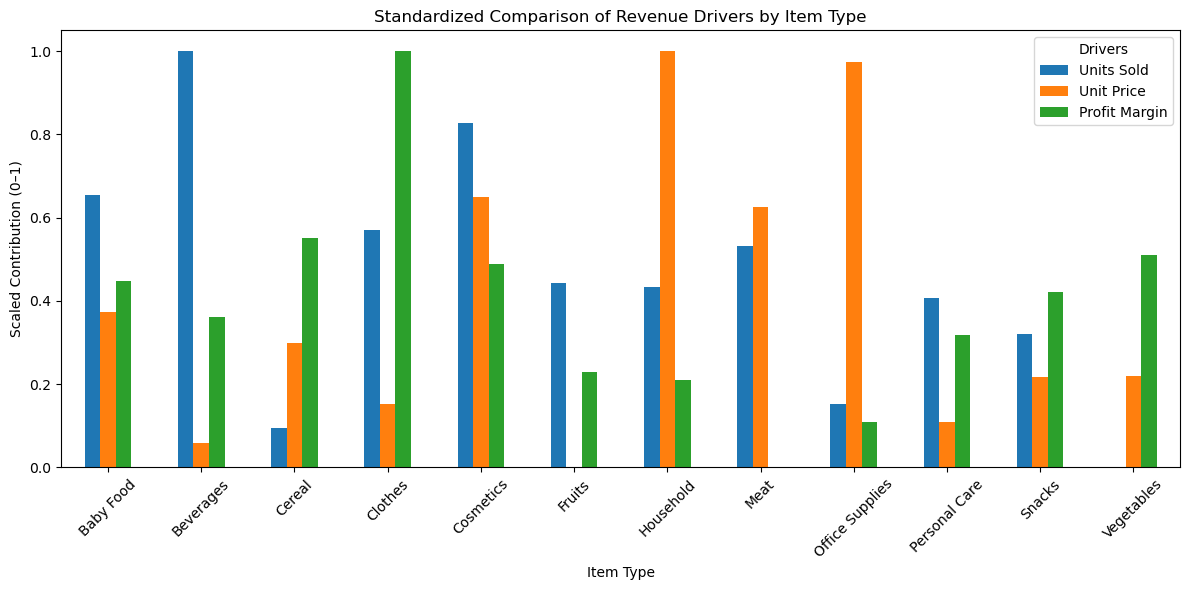

In [17]:
#plot standardized metrics
plt.figure(figsize=(12,6))
metrics_scaled.plot(kind="bar", figsize=(12,6))
plt.title("Standardized Comparison of Revenue Drivers by Item Type")
plt.ylabel("Scaled Contribution (0–1)")
plt.xticks(rotation=45)
plt.legend(title="Drivers")
plt.tight_layout()
plt.show()

##### **Key Insight:**
- **Volume-driven categories:**
    - **Beverages (Units: 1.00 | Price: 0.06):** Maximum volume but rock-bottom pricing. The category generates low revenue despite selling the most units. Proves volume alone cannot drive revenue.
    - **Baby Food (Units: 0.65 | Price: 0.37):** Moderate-high volume with mid-tier pricing. Revenue is decent but not dominant.
    - **Clothes (Units: 0.57 | Price: 0.15):** Volume-leaning, but weak pricing caps revenue potential despite having the highest profit margin.
- **Price-driven categories:** 
    - **Household (Units: 0.43 | Price: 1.00):** Maximum pricing power compensates for moderate volume.
    - **Office Supplies (Units: 0.15 | Price: 0.97):** Extreme premium pricing overcomes very low volume.
    - **Meat (Units: 0.53 | Price: 0.63):** Strong pricing with moderate volume; solid revenue contributor despite zero profit margin.
- **Overall:**
    - Neither volume nor pricing is sufficient to drive revenue. That said, **Cosmetics** dominates because it scores highly in both volume and price **(Unites: 0.83 | Price: 0.65)**

### 4. How Does Revenue Performance Differ Between Sales Channels and Regions, and Are High-Revenue Segments Also High-Margin Segments? 

In [18]:
#aggregate revenue and profit margin by sales channel
channel_metrics = df.groupby("Sales Channel").agg({
    "Total Revenue": "sum",
    "Total Profit": "sum"})

channel_metrics["Profit Margin"] = channel_metrics["Total Profit"] / channel_metrics["Total Revenue"]
channel_metrics

,Total Revenue,Total Profit,Profit Margin
Sales Channel,,,
Offline,79094809.20,24920726.67,0.315074
Online,58253959.11,19247471.73,0.330406


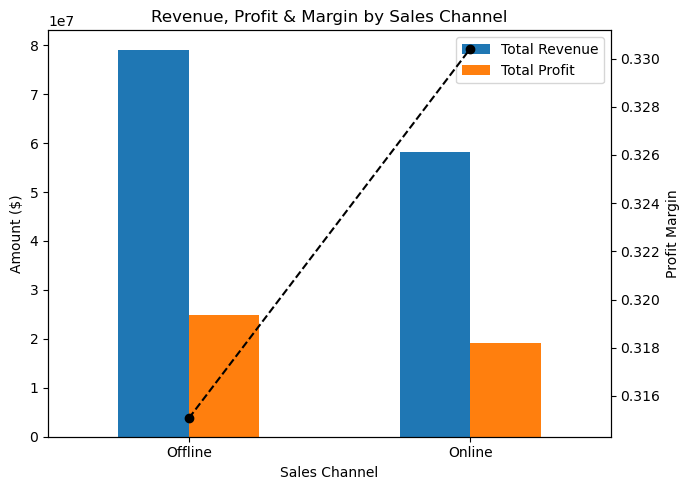

In [19]:
#visualize channel metrics (revenue 
fig, ax1 = plt.subplots(figsize=(7,5))

#revenue and profit bars
channel_metrics[["Total Revenue", "Total Profit"]].plot(
    kind="bar",
    ax=ax1)

ax1.set_ylabel("Amount ($)")
ax1.set_title("Revenue, Profit & Margin by Sales Channel")
ax1.tick_params(axis="x", rotation=0)

#profit margin line (secondary axis)
ax2 = ax1.twinx()
ax2.plot(
    channel_metrics.index,
    channel_metrics["Profit Margin"],
    color="black",
    marker="o",
    linestyle="--")
ax2.set_ylabel("Profit Margin")

plt.tight_layout()
plt.show()

##### Key Insight:
Offline transactions drive scale with **USD 79.09 Million** in revenue and ** USD 24.92 Million** absolute profit. Online transactions demonstrate stronger pricing efficiency with a profit margin of **33.04%**. 

### 5. Based on Revenue Size, Concentration and Efficiency, Which 3 Segments Should Receive Increased Investment, and What Impact on Total Revenue Can Be Expected? 

In [5]:
#aggregate revenue and profit
segment_df = (df.groupby(["Region", "Sales Channel"])
      .agg({"Total Revenue":"sum", "Total Profit":"sum"})
      .reset_index())

#profit margin of each segment
segment_df["Profit Margin"] = segment_df["Total Profit"] / segment_df["Total Revenue"]
#calculate revenue share to understand how much each segment contributes
segment_df["Revenue Share"] = segment_df["Total Revenue"] / segment_df["Total Revenue"].sum()

In [6]:
#standardize above metrics
from scipy.stats import zscore

segment_df["Revenue_z"] = zscore(segment_df["Total Revenue"])
segment_df["Margin_z"] = zscore(segment_df["Profit Margin"])
segment_df["Investment_Score"] = segment_df["Revenue_z"] + segment_df["Margin_z"]

In [8]:
#rank and select the top segments
top3_segments = segment_df.nlargest(3, "Investment_Score")
top3_segments

,Region,Sales Channel,Total Revenue,Total Profit,Profit Margin,Revenue Share,Revenue_z,Margin_z,Investment_Score
11,Sub-Saharan Africa,Offline,25733749.52,7772777.78,0.302046,0.187361,2.394258,-0.577224,1.817033
7,Europe,Online,15246445.66,5508398.72,0.361291,0.111005,0.738895,0.387997,1.126892
2,Australia and Oceania,Offline,4201867.85,1886283.82,0.448916,0.030593,-1.004431,1.815594,0.811162


In [12]:
#estimate revenue and profit impact of investing an additional 10% in top3_segments
uplift_rate = 0.10

#calculate incremental revenue and profit
top3_segments["Incremental Revenue"] = top3_segments["Total Revenue"] * uplift_rate
top3_segments["Incremental Profit"] = top3_segments["Incremental Revenue"] * top3_segments["Profit Margin"]

#sum across top 3 segments
total_revenue_impact = top3_segments["Incremental Revenue"].sum()
total_profit_impact = top3_segments["Incremental Profit"].sum()

#calculate total current revenue and profit across all segments
current_total_revenue = segment_df["Total Revenue"].sum()
current_total_profit = segment_df["Total Profit"].sum()

#calculate % revenue and profit increase
revenue_increase_pct = total_revenue_impact / current_total_revenue * 100
profit_increase_pct = total_profit_impact / current_total_profit * 100

# Print results
print(f"Expected revenue impact: ${total_revenue_impact:,.2f} ({revenue_increase_pct:.2f}%)")
print(f"Expected profit impact: ${total_profit_impact:,.2f} ({profit_increase_pct:.2f}%)")

Expected revenue impact: $4,518,206.30 (3.29%)
Expected profit impact: $1,516,746.03 (3.43%)


**Key Insight**

Investing 10% more in **Sub-Saharan Africa (Offline)**, **Europe (Online)**, and **Australia & Oceania (Offline)** is expected to increase total revenue by **\$4,518,206 (3.3%)** and total profit by **\$1,516,746 (3.4%)**.